ToDo:
- these truth/predicted scatter plots...
    + für spatial mean values
    + für einzelne grid-cells?


- woher stammt varianz?
- varianz für Extremereignisse

changes to implement on server:
- updated utils.torch_to_dataarray()
- added utils.rank_histogram()

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import importlib
import numpy as np
from engression.loss_func import energy_loss, energy_loss_two_sample
import torch
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
import torch, gc
import pickle
import matplotlib.pyplot as plt
import json


device: cpu


# Compare Loss (S1 S2)

# Analogues

In [3]:
# LOAD ORIGINAL DATA

settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
    settings = json.load(file)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])
# Load temperature data
#ds = xr.open_dataset("/Users/friederl/Documents/EcoN_project/LLAAE/DPA/tuning_model3/europe_10percent_masked_stacked_TREFHT_JJA.nc")
ds = xr.open_dataset(settings['dataset_trefht'])


# set train/test split
ds_train = ds.isel(time=slice(0, 128000)) #4769 * 80
ds_test = ds.isel(time=slice(-64000, 476900)) #4769 * 80

# transform to torch tensors
x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te = ut.data_to_torch(ds_test, "TREFHT")

x_entire = ut.data_to_torch(ds, "TREFHT")

# load Z500
ds_z500_pre = xr.open_dataset(settings['dataset_z500'])#xr.open_dataset("/Users/friederl/Documents/EcoN_project/LLAAE/DPA/tuning_model3/GMT_and_pseudoPCs_EOFs_Z500_5daily_100ensmembers_JJA_not_scaled.nc")
ds_z500, _, _ = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 shape", ds_z500.shape)
z500 = torch.from_numpy(ds_z500)
print("z500 shape", z500.shape)


z500_train = z500[:int(128000),:]
z500_test = z500[int(-64000):,:]

# remove NaNs from data
x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
x_te_reduced, mask_x_te = ut.remove_nan_columns(x_te)

x_entire_reduced, mask_x_entire = ut.remove_nan_columns(x_entire)

# create data loader Temperature
#train_dataset = TensorDataset(z500_train, x_tr_reduced)
#train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
#print(f"Number of batches: {len(train_loader)}")

# create test loader Temperature
#test_dataset = TensorDataset(z500_test, x_te_reduced)
#test_loader_in = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
#print(f"Number of batches: {len(test_loader_in)}")

torch.Size([128000, 1024])
torch.Size([64000, 1024])
torch.Size([476900, 1024])
z500 shape (476900, 1001)
z500 shape torch.Size([476900, 1001])


In [34]:
ds_z500_pre

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 476900, mode: 1001)
Coordinates:
  * time        (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode        (mode) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    pseudo_pcs  (time, mode) float32 2GB 941.0 -1.472e+03 ... 0.3043 4.744

In [4]:
importlib.reload(ut)
# load DPA predicted temperatures
# load torch arrays

dpa_t_samples_raw = []
#dpa_t_samples = []
#for i in range(1,98):
    #print(i)
    #t_sample = torch.load(f"/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen{i}_te.pt", map_location=torch.device('cpu'))
    #dpa_t_samples_raw.append(t_sample)
    #dpa_t_sample_restored = ut.restore_nan_columns(t_sample, mask_x_te)
    #dpa_t_samples.append(dpa_t_sample_restored)


##############################
### Create Analogues ###
##############################
predicts_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/"
dpa_t_samples_raw, dpa_t_samples = ut.load_dpa_predicts(predicts_path, mask_x_te)
#dpa_t_samples_raw





1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97


In [6]:
#############################
### Choose any Z500 index ###
#############################

# find max NAO index
idx_max_ar = torch.argmax(z500_test, dim=0)
idx_max = idx_max_ar[10]
print(idx_max)

# find min NAO index
idx_min_ar = torch.argmin(z500_test, dim=0)
idx_min = idx_min_ar[0]
print(idx_min)

tensor(35652)
tensor(24995)


In [9]:
dpa_t_samples_raw[0].shape

torch.Size([64000, 648])

In [24]:
mask_x_te.shape

torch.Size([1024])

In [35]:
importlib.reload(ut)

# DPA ensemble temperatures for Z500 sample
dpa_temps_for_zsample_xr, z500_sample = ut.extract_dpa_tsamples(z500_test, dpa_t_samples_raw, idx_max, coord_ds=ds, mask=mask_x_te)
dpa_temps_for_zsample_xr

(97, 1024)
<class 'torch.Tensor'>
input array is numpy array


<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, time: 97)> Size: 795kB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [ 0.38393441,  1.09981191,  2.71623468, ...,  2.46661568,
         -1.90543127,  1.63172984],
        [ 1.14072168,  2.20595908,  3.10393739, ...,  3.03581429,
         -1.25803232,  2.21863437],
        [ 1.54837954,  2.81322384,  3.74605107, ...,  3.11826468,
         -0.6659652 ,  2.9170289 ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.54016918,  1.89634359,  2.80366921, ...,  3.01204324,
         -1.62125826,  1.65460849],
        [ 0.93867183,  2.71440649,  3.65181446, ...,  3.49932885,
         -1.26591921,  2.19675303],
        [ 1.42323339,  3.36446357,  4.06663704, ...,  3.96294641,
         -0.52031618,  3.41831779]]], shape=(32, 32, 97))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) int64 776B 0 1 2 3 4 5 6 7 8 ... 88 89 90 91 92 93 94 95 96

In [8]:
importlib.reload(ut)
# choose sample from z500 test set
#print(ds_test)
np.random.seed(42)
#index = np.random.randint(0, 64000 + 1, size=100)[0] + 111 # sample index
#idx_max = np.random.randint(0, 64000 + 1, size=100)[0]
#idx_min = np.random.randint(0, 64000 + 1, size=100)[0]
print(idx_max, idx_min)
index = idx_max
print("index:", index)

# extract corresponding Z500 sample/pc score from test set
z500_sample = z500_test[index, :] 
z500_sample_max = z500_test[idx_max, :] # select the sample with e.g. maximum NAO index
z500_sample_min = z500_test[idx_min, :] # select the sample with e.g. minimum NAO index

print("max sample Z500:", z500_sample_max)
print("min sample Z500:", z500_sample_min)


########################
### DPA DISTRIBUTION ###
########################
# generate Temperature distribution with DPA
temps_for_zsample = np.zeros((97, 1024))#[]
temps_for_zsample_raw = np.zeros((97, dpa_t_samples_raw[0].shape[1]))

# extract corresponding (index) temperatures from dpa temperature samples  
# entire spatial field including Nans
for i, sample in enumerate(dpa_t_samples):
    #print(i)
    #print(sample[index, :].shape)
    #temps_for_zsample.append(sample[index, :])
    temps_for_zsample[i,:] = sample[index, :].detach().numpy()

# for raw T-field (without nans)
for i, sample_raw in enumerate(dpa_t_samples_raw):
    #print(i)
    #print(sample[index, :].shape)
    #temps_for_zsample.append(sample[index, :])
    temps_for_zsample_raw[i,:] = sample_raw[index, :].detach().numpy()

print(type(temps_for_zsample))
print((temps_for_zsample.shape))

# transform temps_for_zsample into xarray
temps_for_zsample_xr = ut.torch_to_dataarray(temps_for_zsample, ds, lat_dim=32, lon_dim=32, name="TREFHT")
temps_for_zsample_xr

# not yet necessary for raw

torch.Size([64000, 1001])
tensor(35652) tensor(24995)
index: tensor(35652)
max sample Z500: tensor([ 0.8422,  0.5463,  1.4151,  ...,  0.8473, -0.7569, -0.7739])
min sample Z500: tensor([-3.5582,  1.2262,  0.2821,  ...,  1.4159,  1.3635,  0.9926])
<class 'numpy.ndarray'>
(97, 1024)
input array is numpy array


<xarray.DataArray 'TREFHT' (time: 97)> Size: 776B
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Coordinates:
  * time     (time) int64 776B 0 1 2 3 4 5 6 7 8 ... 88 89 90 91 92 93 94 95 96

In [31]:
############################################
### Compute germany temperature averages ###
############################################

dpa_ger_avgs_pre = temps_for_zsample_xr.sel(lat=slice(48,54), lon=slice(6,15))

# 1) define weights as above
weights = np.cos(np.deg2rad(dpa_ger_avgs_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da = xr.DataArray(weights, coords={'lat': dpa_ger_avgs_pre['lat']}, dims=['lat'])

dpa_ger_avgs = dpa_ger_avgs_pre.weighted(w_da).mean(dim=('lat', 'lon'))
dpa_ger_avgs

<xarray.DataArray 'TREFHT' (time: 97)> Size: 776B
array([-4.01981529, -4.50041984, -3.9401278 , -4.68099863, -3.71419902,
       -4.75144856, -2.66834977, -3.3546808 , -2.87061564, -4.39336536,
       -4.36311589, -5.5023279 , -2.14404744, -2.76906951, -3.06779579,
       -2.6551934 , -4.35154226, -4.15559098, -4.26935591, -5.24451785,
       -3.69458518, -4.17534785, -3.82609112, -5.4525464 , -5.28131462,
       -3.77211419, -4.26366818, -2.75728561, -3.49164348, -3.87183013,
       -3.95245114, -3.99925011, -4.87025503, -4.32223205, -5.07044094,
       -3.09144282, -4.13265903, -3.58590454, -6.27843778, -3.92498868,
       -3.98585079, -3.35917082, -3.35097091, -4.57931287, -4.06214562,
       -3.65834798, -3.70405674, -5.07630071, -4.70132476, -3.86351778,
       -3.36159048, -4.17502935, -4.9483562 , -4.11941193, -3.98141814,
       -4.49503611, -4.67375246, -4.60863756, -4.7602036 , -3.69147074,
       -4.68325132, -3.26666639, -3.92578771, -3.48045135, -4.03472978,
       -3.71702008, -2.72628349, -4.76340023, -4.26825194, -4.58189176,
       -3.6517617 , -5.04171422, -5.00710142, -4.15277851, -3.49946754,
       -3.6931843 , -2.14853975, -3.99791234, -4.48043656, -3.27589755,
       -3.29444252, -3.44305831, -4.03130435, -3.40587857, -5.23377292,
       -3.43667308, -2.27172106, -4.07272102, -4.16890156, -4.09389308,
       -4.37766265, -6.5625655 , -3.81782066, -4.8591197 , -3.24954827,
       -4.55656898, -4.13541746])
Coordinates:
  * time     (time) int64 776B 0 1 2 3 4 5 6 7 8 ... 88 89 90 91 92 93 94 95 96

In [40]:
importlib.reload(ut)
nearest_temps, top_idxs = ut.find_analogues(ds.TREFHT, ds_z500_pre.pseudo_pcs.values, z500_sample, no_pcs = 100, no_nearest = 97)

In [10]:
#########################
### DATASET ANALOGUES ###
#########################
# find analogues in ds_z500_pre (ens membs 0-100)
# number of pcs to compare
no_pcs = 100 #5
diff  = ds_z500_pre.pseudo_pcs.values[:,:no_pcs] - z500_sample.numpy()[:no_pcs]
diff_max  = ds_z500[:,:no_pcs] - z500_sample_max.numpy()[:no_pcs] # ds_z500_pre isn't standardized
diff_min  = ds_z500[:,:no_pcs] - z500_sample_min.numpy()[:no_pcs]



print("diff_max:", diff_max[0,:10])
print("diff_min:", diff_min[0,:10])


dists = np.linalg.norm(diff, axis=1)  
dists_max = np.linalg.norm(diff_max, axis=1)  
dists_min = np.linalg.norm(diff_min, axis=1)  

print("dists_max:", dists_max)
print("dists_min:", dists_min)

# 2) find the no_nearest smallest distances
no_nearest = 97
top100_idx = np.argsort(dists)[:no_nearest]   # indices of the no_pcs nearest rows
top100_idx_max = np.argsort(dists_max)[:no_nearest]   # indices of the no_pcs nearest rows
top100_idx_min = np.argsort(dists_min)[:no_nearest]   # indices of the no_pcs nearest rows


nearest_pcs_raw = x_entire_reduced[top100_idx,:]
nearest_pcs_max = ds.TREFHT.isel(time=top100_idx_max) 

print("Indices of nearest neighbors:", top100_idx[:10])
print("NAO+: Indices of nearest neighbors:", top100_idx_max[:10])
print("NAO-: Indices of nearest neighbors:", top100_idx_min[:10])

#print("Their distances:", dists[top100_idx])
#print("Nearest pcs Temperatures shape:", nearest_pcs.shape)
#print("Nearest pcs raw Temperatures shape:", nearest_pcs_raw.shape)

# resulting temperature
#print(nearest_pcs.shape)
# generate corresponding Temperature distribution

diff_max: [-0.40788195 -1.2494874  -2.6081915  -0.4017371   3.1379209   1.2234459
  1.4861623   1.2028589   2.8272948   3.017187  ]
diff_min: [ 3.9924724  -1.9293373  -1.4752281   0.650275    2.3786595   2.8304157
 -1.7055401  -0.09495234  3.82733     2.121903  ]
dists_max: [19.288609 18.65153  16.769676 ... 14.323472 15.935509 14.252538]
dists_min: [17.177925 14.806796 14.640337 ... 12.711004 15.311813 15.334805]
Indices of nearest neighbors: [203575 340384 132881 269677 464680  71322 185796 339559 374082 452630]
NAO+: Indices of nearest neighbors: [448552 419378  49909 247506 368312 390196 225313 458005  85175 249044]
NAO-: Indices of nearest neighbors: [437895 261274 107118 466250 290124 208940 290535 224361 212600  61212]


In [ ]:
# extract dpa samples i.e., dpa ensemble of specific circulation
#temps_for_zsample_xr = ut.extract_dpa_tsamples(z500_test, dpa_t_samples_raw)
# find analogues

In [8]:
# ENERGY LOSS between analogues and DPA predicted distribution
from engression.loss_func import energy_loss, energy_loss_two_sample

##############################################
##############################################    
##############################################    

# DPA predicted distribution
dpa_ensemble = torch.tensor(temps_for_zsample_raw)
print(dpa_ensemble.shape)
rows_list = [dpa_ensemble[i].unsqueeze(0) for i in range(a.size(0))]
print((rows_list[0].shape))

# analogue distribution 
#analogue_distr = ut.data_to_torch(nearest_pcs.to_dataset(), "TREFHT") # function requires dataset as input
print(nearest_pcs_raw.shape)

# compute energy score

nrgy_analog_losses = []
s1_analog_losses = []
s2_analog_losses = []
for i in range(nearest_pcs_raw.shape[0]):
    #print(i)
    energy_loss_analogues = energy_loss(nearest_pcs_raw[i,:], rows_list, beta=1)
    nrgy_analog_losses.append(energy_loss_analogues[0])
    s1_analog_losses.append(energy_loss_analogues[1])
    s2_analog_losses.append(energy_loss_analogues[2])

mean_nrgy_loss = sum(nrgy_analog_losses) / len(nrgy_analog_losses)
mean_s1_loss = sum(s1_analog_losses) / len(s1_analog_losses)
mean_s2_loss = sum(s2_analog_losses) / len(s2_analog_losses)

print("Mean energy loss:", mean_nrgy_loss)
print("Mean S1 loss:", mean_s1_loss)
print("Mean S2 loss:", mean_s2_loss)

for l, loss in enumerate(s1_analog_losses):
    print(loss, s2_analog_losses[l])
#print(s2_analog_losses)
#print(energy_loss_analogues)

torch.Size([97, 648])


NameError: name 'a' is not defined

In [ ]:
# NRGY MAP: Spatially resolve energy loss
import matplotlib.colors as mcolors

#nrgy_map = np.zeros((32,32))
#for lat_idx in range(0,32):
#    for lon_idx in range(0,32):
#        # truth
#        truth_gc = ds_test.TREFHT.isel(lat=lat_idx, lon=lon_idx).values
#        
#        # dpa predicted samples
#        # turn into xarray
#        dpa_t_sample_restored_xr1 = ut.torch_to_dataarray(dpa_t_samples[0].detach(), ds_test, lat_dim=32, lon_dim=32, name="TREFHT").isel(lat=20, lon=20)
#        dpa_t_sample_restored_xr2 = ut.torch_to_dataarray(dpa_t_samples[1].detach(), ds_test, lat_dim=32, lon_dim=32, name="TREFHT").isel(lat=20, lon=20)
#        
#        preds1 = dpa_t_sample_restored_xr1.values
#        preds2 = dpa_t_sample_restored_xr2.values
#        #for i in range(96):
#        nrgy_loss = ut.energy_loss_two_sample(torch.tensor(truth_gc),
#                                               torch.tensor(preds1),
#                                               torch.tensor(preds2))
#        nrgy_map[lat_idx, lon_idx] = nrgy_loss[0]

# compute energy loss for entire generated distribution
nrgy_map = np.zeros((32,32))
for lat_idx in range(0,32):
    for lon_idx in range(0,32):
        # grid-cell
        gc = lat_idx * lon_idx
        print(gc)
        # truth
        truth_gc = x_te[:,gc].unsqueeze(1) #add 2nd dimension #ds_test.TREFHT.isel(lat=lat_idx, lon=lon_idx).values
        print(truth_gc.shape)

        # turn list of 
        column_list = [t[:, gc:gc+1] for t in dpa_t_samples]

        # Check shapes
        #for i, col in enumerate(column_list):
        #    print(f"Tensor {i} column shape: {col.shape}")
        print((column_list[0].shape))
        nrgy_loss = energy_loss(truth_gc, column_list)
        nrgy_map[lat_idx, lon_idx] = nrgy_loss[0]
        
#        preds1 = dpa_t_sample_restored_xr1.values
#        preds2 = dpa_t_sample_restored_xr2.values
#        #for i in range(96):
#        nrgy_loss = ut.energy_loss(,
#                                    )
#        nrgy_map[lat_idx, lon_idx] = nrgy_loss[0]
    
print(nrgy_loss)
# define boundaries and a matching colormap
bounds = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]             # intervals
cmap   = plt.cm.viridis
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure()

im = plt.imshow(nrgy_map, origin = 'lower', cmap=cmap, norm=norm)
# Add a colorbar, linked to the image
cbar = plt.colorbar(im)
cbar.set_label('Value')  # optional: label the colorbar
plt.show()


# plot with cartopy
# 3a) Create a DataArray
dataarray = xr.DataArray(
    data     = nrgy_map,
    dims     = ("latitude", "longitude"),
    coords   = {"latitude": ds_test.TREFHT.lat.values, "longitude": ds_test.TREFHT.lon.values},
    name     = "EnergyScore",          # optional “variable name”
    attrs    = {"units": "unitless"},         # optional metadata
)
#fig, ax = plt.subplots() 
#ut.plot_temperature_panel(ax, dataarray, vmax_shared = 3)

In [42]:
# compute germany average of analogues
# computed manually
#ger_avg_anlgs = nearest_pcs.sel(lat=slice(48,54), lon=slice(6,15)).weighted(w_da).mean(dim=('lat', 'lon'))

# computed from utility script
ger_avg_anlgs = nearest_temps.sel(lat=slice(48,54), lon=slice(6,15)).weighted(w_da).mean(dim=('lat', 'lon'))

ger_avg_anlgs
# compare distributions (energy score)

<xarray.DataArray 'TREFHT' (time: 97)> Size: 776B
array([ 3.18698812,  0.15511873,  1.92393637,  1.03675065,  1.18775495,
        7.73482084,  5.65346431,  1.70361786, -0.17466739,  5.73233952,
        1.55466339,  5.20780005,  1.30618017,  3.69753889,  0.73688396,
       -0.61238077, -2.42318887, -0.79716472,  0.22394312,  1.39486692,
        2.31136919, -1.5862014 , -0.6099731 ,  7.50058388,  1.02516766,
        0.44120508, -0.86781492,  3.16802959,  0.95665492,  2.40598285,
        3.09251513, -0.65223138,  2.12544937,  2.01123877,  1.26673624,
        1.9901581 ,  2.34319861, -3.75144036, -2.7207235 ,  3.84303707,
        1.54489807,  0.98104477,  0.45295306, -0.54559232,  3.17710684,
        5.75284322, -1.62883231,  4.03580818, -1.89907113,  5.02016319,
       -1.50192263, -0.27352733,  0.36562896,  0.1157736 ,  0.17890706,
       -2.5211086 ,  2.92844698,  2.27675974, -1.90930435,  5.84838008,
        0.81113961, -1.1572341 ,  0.26228106,  1.88646049,  7.31384447,
        0.64489787, -0.6103027 ,  1.00142707,  3.54549608, -0.8009953 ,
        3.13131457, -0.54025115,  1.56548374,  2.38085553,  4.77289558,
       -0.72762163,  2.34820519, -0.22773472, -0.01306276,  2.61150468,
        2.52445432, -0.39564421,  4.17770021,  3.59370732,  2.34152117,
       -1.86021222,  3.08355632, -1.81962025,  0.46697821,  4.03619617,
        2.67420484, -0.20729903,  3.06388638,  7.68040962,  5.71236358,
        4.91089638, -0.27912519])
Coordinates:
  * time     (time) object 776B 2022-07-17 00:00:00 ... 2005-08-21 00:00:00

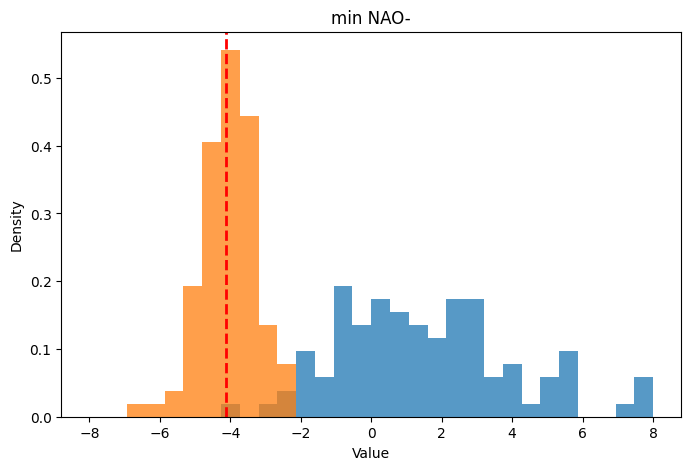

Now can calculate Energy Scores for predicted and analogue distribution ...


In [45]:
# Define the range you care about:
value_min, value_max = -8.0, 8.0
index = idx_max

# Plot histogram with that range
plt.figure(figsize=(8, 5))

# analogue Temperature distribution
plt.hist(
    ger_avg_anlgs_max.values,
    bins=30,
    range=(value_min, value_max),   # <-- only from -2.0 to 2.0
    density=True,
    alpha=0.75
)

# dpa generated distribution
plt.hist(
    dpa_ger_avgs.values,
    bins=30,
    range=(value_min, value_max),   # <-- only from -2.0 to 2.0
    density=True,
    alpha=0.75
)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title(f"min NAO-")


# include actual value here!!
true_temp = ds_test.TREFHT.sel(lat=slice(48,54), lon=slice(6,15)).isel(time=index).weighted(w_da).mean(dim=('lat', 'lon')).values
plt.axvline(x=true_temp, color='red', linestyle='--', linewidth=2,
            label=f'x = {true_temp}')
plt.show()
print("Now can calculate Energy Scores for predicted and analogue distribution ...")

# Rank Histograms

## Germany average

In [13]:
# true values - germany spatial average
temp_true = ds_test.sel(lat=slice(48,54), lon=slice(6,15)).sel(lat=slice(48,54), lon=slice(6,15)).mean(dim=('lat', 'lon'))
temp_true

<xarray.Dataset> Size: 768kB
Dimensions:  (time: 64000)
Coordinates:
  * time     (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (time) float32 256kB 1.79 1.871 2.739 2.423 ... 7.844 7.737 9.18

In [15]:
# DPA predicted values
dpa_t_samples_weighted_ger_avgs = np.zeros((64000,97))#[]
for i in range(1,98):
    print(i)
    t_sample = torch.load(f"/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen{i}_te.pt", map_location=torch.device('cpu'))
    dpa_t_sample_restored = ut.restore_nan_columns(t_sample, mask_x_te)
    
    # turn into xarray
    dpa_t_sample_restored_xr = ut.torch_to_dataarray(dpa_t_sample_restored.detach(), ds, lat_dim=32, lon_dim=32, name="TREFHT")
    
    # compute weighted germany spatial average
    ger_avg = dpa_t_sample_restored_xr.sel(lat=slice(48,54), lon=slice(6,15)).weighted(w_da).mean(dim=('lat', 'lon'))
    #print(ger_avg.shape)
    dpa_t_samples_weighted_ger_avgs[:,i-1] = ger_avg

print(dpa_t_samples_weighted_ger_avgs.shape)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
(64000, 97)


(64000,)
(64000, 97)
(64000,)
(64000, 97)


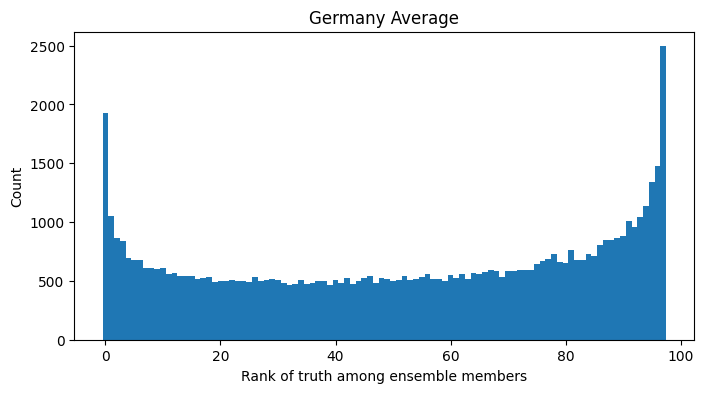

In [17]:
importlib.reload(ut)

print(temp_true.TREFHT.shape)
print(dpa_t_samples_weighted_ger_avgs.shape)

truth = temp_true.TREFHT
print(truth.shape)
ensemble = dpa_t_samples_weighted_ger_avgs
print(ensemble.shape)

# 2) compute ranks
ranks = ut.rank_histogram(truth, ensemble)
n_members = ensemble.shape[1]

# 3) plot histogram of ranks
plt.figure(figsize=(8,4))
# bins from 0..n_members inclusive
plt.hist(ranks, bins=np.arange(n_members+2)-0.5)#, edgecolor='black')
#plt.xticks(np.arange(n_members+1))
plt.xlabel('Rank of truth among ensemble members')
plt.ylabel('Count')
plt.title('Germany Average')
plt.show()

# --> looks like a bias, DPA overestimates values

In [18]:
# energy loss for spatial mean values
importlib.reload(ut)


for i in range(96):
    nrgy_loss = ut.energy_loss_two_sample(torch.tensor(temp_true.TREFHT.values),
                                       torch.tensor(dpa_t_samples_weighted_ger_avgs[:,i]),
                                       torch.tensor(dpa_t_samples_weighted_ger_avgs[:,i+1]))
    print(nrgy_loss)

# energy loss für distribution an vorhersagen

tensor([0.6140, 1.0688, 0.9095], dtype=torch.float64)
tensor([0.6126, 1.0670, 0.9090], dtype=torch.float64)
tensor([0.6119, 1.0669, 0.9101], dtype=torch.float64)
tensor([0.6094, 1.0646, 0.9103], dtype=torch.float64)
tensor([0.6064, 1.0642, 0.9155], dtype=torch.float64)
tensor([0.6108, 1.0672, 0.9128], dtype=torch.float64)
tensor([0.6094, 1.0652, 0.9114], dtype=torch.float64)
tensor([0.6069, 1.0629, 0.9120], dtype=torch.float64)
tensor([0.6097, 1.0650, 0.9106], dtype=torch.float64)
tensor([0.6089, 1.0644, 0.9111], dtype=torch.float64)
tensor([0.6099, 1.0635, 0.9073], dtype=torch.float64)
tensor([0.6121, 1.0661, 0.9081], dtype=torch.float64)
tensor([0.6123, 1.0679, 0.9113], dtype=torch.float64)
tensor([0.6106, 1.0670, 0.9129], dtype=torch.float64)
tensor([0.6101, 1.0653, 0.9105], dtype=torch.float64)
tensor([0.6095, 1.0641, 0.9092], dtype=torch.float64)
tensor([0.6097, 1.0643, 0.9092], dtype=torch.float64)
tensor([0.6080, 1.0641, 0.9121], dtype=torch.float64)
tensor([0.6079, 1.0616, 0.90

## Central France-average

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
(64000, 97)
(64000,)
(64000, 97)


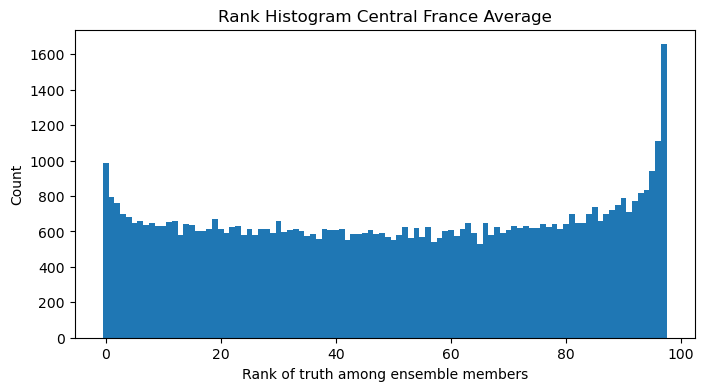

In [73]:
fr_lat_min = 45
fr_lat_max = 50
fr_lon_min = 0
fr_lon_max = 5

# true values - france spatial average
temp_true_fr = ds_test.sel(lat=slice(fr_lat_min,fr_lat_max), lon=slice(fr_lon_min,fr_lon_max)).mean(dim=('lat', 'lon'))
temp_true_fr

# DPA predicted values
dpa_t_samples_weighted_fr_avgs = np.zeros((64000,97))#[]
for i in range(1,98):
    print(i)
    t_sample = torch.load(f"/Users/friederl/Documents/EcoN_project/LLAAE/DPA/tuning_model3/gen{i}_te.pt", map_location=torch.device('cpu'))
    dpa_t_sample_restored = ut.restore_nan_columns(t_sample, mask_x_te)
    
    # turn into xarray
    dpa_t_sample_restored_xr = ut.torch_to_dataarray(dpa_t_sample_restored.detach(), ds, lat_dim=32, lon_dim=32, name="TREFHT")
    
    # compute germany spatial average
    ger_avg = dpa_t_sample_restored_xr.sel(lat=slice(fr_lat_min,fr_lat_max), lon=slice(fr_lon_min,fr_lon_max)).weighted(w_da).mean(dim=('lat', 'lon'))
    #print(ger_avg.shape)
    dpa_t_samples_weighted_fr_avgs[:,i-1] = ger_avg

print(dpa_t_samples_weighted_fr_avgs.shape)

print(temp_true_fr.TREFHT.shape)
print(dpa_t_samples_weighted_fr_avgs.shape)

truth_fr = temp_true_fr.TREFHT
ensemble_fr = dpa_t_samples_weighted_fr_avgs

# 2) compute ranks
ranks = ut.rank_histogram(truth_fr, ensemble_fr)

# 3) plot histogram of ranks
plt.figure(figsize=(8,4))
# bins from 0..n_members inclusive
plt.hist(ranks, bins=np.arange(n_members+2)-0.5)#, edgecolor='black')
#plt.xticks(np.arange(n_members+1))
plt.xlabel('Rank of truth among ensemble members')
plt.ylabel('Count')
plt.title('Central France Average')
plt.show()

# --> looks like a bias, DPA overestimates values

In [77]:
print(np.arange(n_members+2)-0.5)

[-0.5  0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5
 13.5 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5
 27.5 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5 38.5 39.5 40.5
 41.5 42.5 43.5 44.5 45.5 46.5 47.5 48.5 49.5 50.5 51.5 52.5 53.5 54.5
 55.5 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5 65.5 66.5 67.5 68.5
 69.5 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5 79.5 80.5 81.5 82.5
 83.5 84.5 85.5 86.5 87.5 88.5 89.5 90.5 91.5 92.5 93.5 94.5 95.5 96.5
 97.5]


## Spain

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
(64000, 97)
(64000,)
(64000, 97)


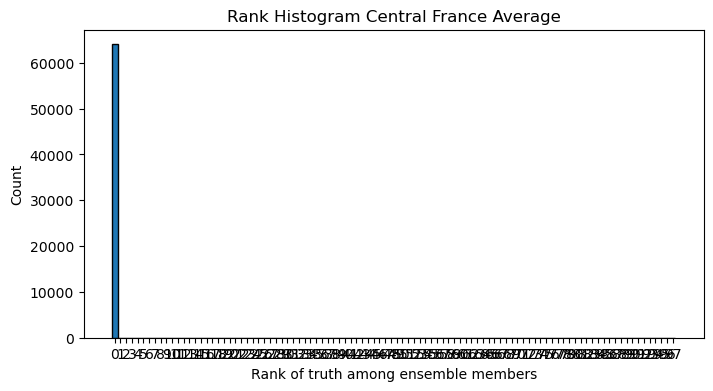

In [78]:
fr_lat_min = 38
fr_lat_max =42
fr_lon_min = -2
fr_lon_max = 0

# true values - france spatial average
temp_true_fr = ds_test.sel(lat=slice(fr_lat_min,fr_lat_max), lon=slice(fr_lon_min,fr_lon_max)).mean(dim=('lat', 'lon'))
temp_true_fr

# DPA predicted values
dpa_t_samples_weighted_fr_avgs = np.zeros((64000,97))#[]
for i in range(1,98):
    print(i)
    t_sample = torch.load(f"/Users/friederl/Documents/EcoN_project/LLAAE/DPA/tuning_model3/gen{i}_te.pt", map_location=torch.device('cpu'))
    dpa_t_sample_restored = ut.restore_nan_columns(t_sample, mask_x_te)
    
    # turn into xarray
    dpa_t_sample_restored_xr = ut.torch_to_dataarray(dpa_t_sample_restored.detach(), ds, lat_dim=32, lon_dim=32, name="TREFHT")
    
    # compute germany spatial average
    ger_avg = dpa_t_sample_restored_xr.sel(lat=slice(fr_lat_min,fr_lat_max), lon=slice(fr_lon_min,fr_lon_max)).weighted(w_da).mean(dim=('lat', 'lon'))
    #print(ger_avg.shape)
    dpa_t_samples_weighted_fr_avgs[:,i-1] = ger_avg

print(dpa_t_samples_weighted_fr_avgs.shape)

print(temp_true_fr.TREFHT.shape)
print(dpa_t_samples_weighted_fr_avgs.shape)

truth_fr = temp_true_fr.TREFHT
ensemble_fr = dpa_t_samples_weighted_fr_avgs

# 2) compute ranks
ranks = ut.rank_histogram(truth_fr, ensemble_fr)

# 3) plot histogram of ranks
plt.figure(figsize=(8,4))
# bins from 0..n_members inclusive
plt.hist(ranks, bins=np.arange(n_members+2)-0.5, edgecolor='black')
plt.xticks(np.arange(n_members+1))
plt.xlabel('Rank of truth among ensemble members')
plt.ylabel('Count')
plt.title('Rank Histogram Central France Average')
plt.show()

# --> looks like a bias, DPA overestimates values

In [63]:
ds_test

<xarray.Dataset> Size: 263MB
Dimensions:  (lat: 32, lon: 32, time: 64000)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 262MB ...